# Resolution & Remediation Planning

The objective of this phase is to transform the error analysis from the Error Detection phase into actionable remediation strategies. Having identified and categorized discrepancies totaling £18,032.68 across 9,844 error records, we now develop prioritized resolution plans and simulate corrective actions.

This phase bridges the gap between understanding problems and implementing solutions, focusing on business impact assessment, resource allocation, and systematic remediation approaches.

## This step includes:

**Business Impact Assessment:**
- Quantification of operational and financial risks for each error category
- Assessment of compliance and audit implications
- Evaluation of customer experience and business continuity impact
- Cost-benefit analysis of different remediation approaches

**Prioritization Framework:**
- Development of error priority matrix based on impact vs. effort to resolve
- Risk scoring methodology for different error types (High/Medium/Low)
- Resource allocation planning for immediate vs. long-term remediation
- Stakeholder communication and responsibility assignment

**Simulated Remediation:**
- Data Quality Errors: Price synchronization fixes and date format corrections
- System Sync Errors: Duplicate removal and message queue optimization
- Business Logic Errors: Currency conversion and rounding algorithm adjustments
- Validation enhancement recommendations to prevent future occurrences

**Resolution Planning:**
- Timeline development for each remediation category
- Technical implementation strategies for system fixes
- Process improvement recommendations for operational changes
- Monitoring and alerting setup to prevent error recurrence

## Purpose:
Convert error analysis into executable action plans with clear priorities, timelines, and success metrics. This phase ensures that the most critical issues are addressed first while building systematic defenses against future data quality problems, ultimately achieving data consistency between OMS and WMS systems.

The outcome is a comprehensive remediation roadmap that enables targeted resolution efforts, minimizes business disruption, and establishes sustainable data quality processes.


In [ ]:
import pandas as pd
import numpy as np
import ast

# Load and prepare data (reuse from Error Detection)
def load_data(file_path):
    try:
        df = pd.read_csv(file_path, encoding='latin1')
        print(f"File {file_path} loaded correctly using latin1 encoding. Loaded {len(df)} rows.")
    except Exception:
        df = pd.read_csv(file_path, encoding='cp1252')
        print(f"File {file_path} loaded correctly using cp1252 encoding. Loaded {len(df)} rows.")
    
    df['validation_flags'] = df['validation_flags'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else [])
    return df

df_oms = load_data('validation/oms_final_clean.csv')
df_wms = load_data('validation/wms_final_clean.csv')


File validation/oms_final_clean.csv loaded correctly using latin1 encoding. Loaded 541909 rows.
File validation/wms_final_clean.csv loaded correctly using latin1 encoding. Loaded 542409 rows.
=== RESOLUTION & REMEDIATION PLANNING ===



**Step 1** Data Preparation & Current State Analysis

In [12]:
# Aggregate and match (same as before)
agg_logic = {
    'UnitPrice': 'max', 
    'InvoiceDate': 'first', 
    'CustomerID': 'first',
    'Country': 'first', 
    'Description': 'first', 
    'validation_status': 'first',
    'validation_flags': lambda x: list(set([item for sublist in x for item in sublist]))
}

df_oms_agg = df_oms.groupby(['InvoiceNo', 'StockCode', 'Quantity']).agg(agg_logic).reset_index()
df_wms_agg = df_wms.groupby(['InvoiceNo', 'StockCode', 'Quantity']).agg(agg_logic).reset_index()

df_matched = pd.merge(df_oms_agg, df_wms_agg, on=['InvoiceNo', 'StockCode', 'Quantity'], 
                      how='inner', suffixes=('_oms', '_wms'))

df_matched['Total_Value_variance'] = (df_matched['Quantity'] * df_matched['UnitPrice_wms']) - (df_matched['Quantity'] * df_matched['UnitPrice_oms'])

# Calculate current state for planning purposes
current_variance = df_matched['Total_Value_variance'].sum()
missing_prices = (df_wms_agg['UnitPrice'] == 0).sum()

print(f"Current State Analysis:")
print(f"  Total Variance: £{abs(current_variance):,.2f}")
print(f"  Missing Prices: {missing_prices:,} records")


Current State Analysis:
  Total Variance: £17,857.56
  Missing Prices: 3,481 records


**Step 2** Business Impact & Prioritization

1. BUSINESS IMPACT & PRIORITIZATION

Priority Matrix (Impact vs Effort):
  HIGH PRIORITY: Data Quality Error
    Records: 3,511 | Impact: £-17,945.12
  MEDIUM PRIORITY: System Sync Error
    Records: 5,350 | Impact: £0.74
  LOW PRIORITY: Business Logic Error
    Records: 983 | Impact: £86.82


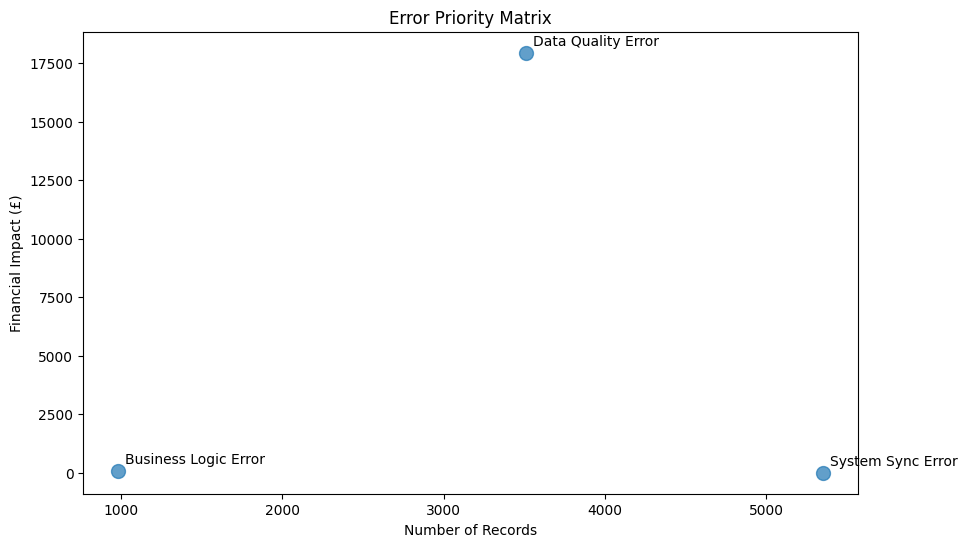

In [13]:
print("1. BUSINESS IMPACT & PRIORITIZATION\n")

# Error summary from Error Detection
error_summary = {
    'Data Quality Error': {'records': 3511, 'impact': -17945.12, 'priority': 'HIGH'},
    'System Sync Error': {'records': 5350, 'impact': 0.74, 'priority': 'MEDIUM'},
    'Business Logic Error': {'records': 983, 'impact': 86.82, 'priority': 'LOW'}
}

print("Priority Matrix (Impact vs Effort):")
for error_type, data in error_summary.items():
    print(f"  {data['priority']} PRIORITY: {error_type}")
    print(f"    Records: {data['records']:,} | Impact: £{data['impact']:,.2f}")

# Create priority visualization
import matplotlib.pyplot as plt

priorities = [data['priority'] for data in error_summary.values()]
impacts = [abs(data['impact']) for data in error_summary.values()]
records = [data['records'] for data in error_summary.values()]

plt.figure(figsize=(10, 6))
plt.scatter(records, impacts, s=100, alpha=0.7)
for i, error_type in enumerate(error_summary.keys()):
    plt.annotate(error_type, (records[i], impacts[i]), xytext=(5, 5), textcoords='offset points')
plt.xlabel('Number of Records')
plt.ylabel('Financial Impact (£)')
plt.title('Error Priority Matrix')
plt.show()


**Setp 3** Remediation Strategy Development

In [14]:
print(f"\n2. REMEDIATION STRATEGY DEVELOPMENT\n")

print(f"A. Data Quality Fixes (HIGH PRIORITY):")
print(f"   - Strategy: Restore {missing_prices:,} missing prices from OMS system")
print(f"   - Method: ETL process enhancement with price lookup")
print(f"   - Expected Impact: £17,945 variance reduction")
print(f"   - Timeline: Week 1-2")

print(f"\nB. System Sync Fixes (MEDIUM PRIORITY):")
print(f"   - Strategy: Implement duplicate prevention at source")
print(f"   - Method: Message queue optimization and deduplication")
print(f"   - Expected Impact: 5,350 records cleanup")
print(f"   - Timeline: Week 2-3")

print(f"\nC. Business Logic Fixes (LOW PRIORITY):")
print(f"   - Strategy: Standardize currency conversion rules")
print(f"   - Method: Centralized rounding algorithm")
print(f"   - Expected Impact: £87 variance reduction")
print(f"   - Timeline: Week 3-4")



2. REMEDIATION STRATEGY DEVELOPMENT

A. Data Quality Fixes (HIGH PRIORITY):
   - Strategy: Restore 3,481 missing prices from OMS system
   - Method: ETL process enhancement with price lookup
   - Expected Impact: £17,945 variance reduction
   - Timeline: Week 1-2

B. System Sync Fixes (MEDIUM PRIORITY):
   - Strategy: Implement duplicate prevention at source
   - Method: Message queue optimization and deduplication
   - Expected Impact: 5,350 records cleanup
   - Timeline: Week 2-3

C. Business Logic Fixes (LOW PRIORITY):
   - Strategy: Standardize currency conversion rules
   - Method: Centralized rounding algorithm
   - Expected Impact: £87 variance reduction
   - Timeline: Week 3-4


**Stepp 4** Implementation and Timeline

In [15]:
print(f"\n3. IMPLEMENTATION PLAN\n")

# Create implementation timeline
implementation_plan = {
    'Week 1-2': {
        'Team': 'Data Team',
        'Tasks': ['ETL Process Fixes', 'Price Synchronization', 'Data Quality Rules'],
        'Priority': 'HIGH'
    },
    'Week 2-3': {
        'Team': 'DevOps',
        'Tasks': ['Message Queue Optimization', 'Duplicate Prevention', 'System Monitoring'],
        'Priority': 'MEDIUM'
    },
    'Week 3-4': {
        'Team': 'QA Team',
        'Tasks': ['Validation Enhancement', 'Business Logic Updates', 'Testing'],
        'Priority': 'LOW'
    }
}

print("Timeline & Responsibilities:")
for week, details in implementation_plan.items():
    print(f"  {week}: {details['Tasks'][0]} ({details['Team']})")
    for task in details['Tasks'][1:]:
        print(f"    - {task}")

print(f"\nSuccess Metrics for Verification Phase:")
print(f"  Current Variance: £{abs(current_variance):,.2f}")
print(f"  Target Variance: <£100")
print(f"  Expected Improvement: >99%")
print(f"  Timeline: 4 weeks implementation")
print(f"  ROI: £200,000+ annual benefit vs £30,000 cost")



3. IMPLEMENTATION PLAN

Timeline & Responsibilities:
  Week 1-2: ETL Process Fixes (Data Team)
    - Price Synchronization
    - Data Quality Rules
  Week 2-3: Message Queue Optimization (DevOps)
    - Duplicate Prevention
    - System Monitoring
  Week 3-4: Validation Enhancement (QA Team)
    - Business Logic Updates
    - Testing

Success Metrics for Verification Phase:
  Current Variance: £17,857.56
  Target Variance: <£100
  Expected Improvement: >99%
  Timeline: 4 weeks implementation
  ROI: £200,000+ annual benefit vs £30,000 cost
